# Steam Turbine Predictive Maintenance using Machine Learning

This project investigates anomaly detection techniques for steam turbine monitoring data using:

- Correlation Analysis
- Outlier Detection
- KNN Regression
- Autoencoders
- PCA + Mahalanobis Distance
- SARIMA Forecasting

The goal is early fault detection for rotating equipment and predictive maintenance applications.

In [ ]:
import os
import pandas as pd
import numpy as np
from sklearn import preprocessing
import seaborn as sns
from scipy import stats
sns.set(color_codes=True)
import matplotlib.pyplot as plt
%matplotlib inline

from numpy.random import seed
#from tensorflow import set_random_seed

from keras.layers import Input, Dropout
from keras.layers.core import Dense 
from keras.models import Model, Sequential, load_model
from keras import regularizers
from keras.models import model_from_json

import matplotlib.pyplot as plt
import os
import seaborn as sns
from tensorflow import keras

from sklearn import preprocessing

sns.set(color_codes=True)
import matplotlib.pyplot as plt
%matplotlib inline

from numpy.random import seed
import tensorflow as tf
from keras.layers import Input, Dropout
from keras.layers.core import Dense 
from keras.models import Model, Sequential, load_model
from keras import regularizers
from keras.models import model_from_json

# 1. Preprocessing

In [2]:
#Convert from xlsx to csv
#read_file = pd.read_excel (r"C:\Users\halim\Downloads\Data BFPT A SLA6 180 hari 5 min Newest Original.xlsx")
#read_file.to_csv (r"C:\Users\halim\Downloads\Data BFPT A SLA6 180 hari 5 min Newest Original.csv", index = None, header=True)

C:\Users\halim\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3063: DtypeWarning: Columns (104) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


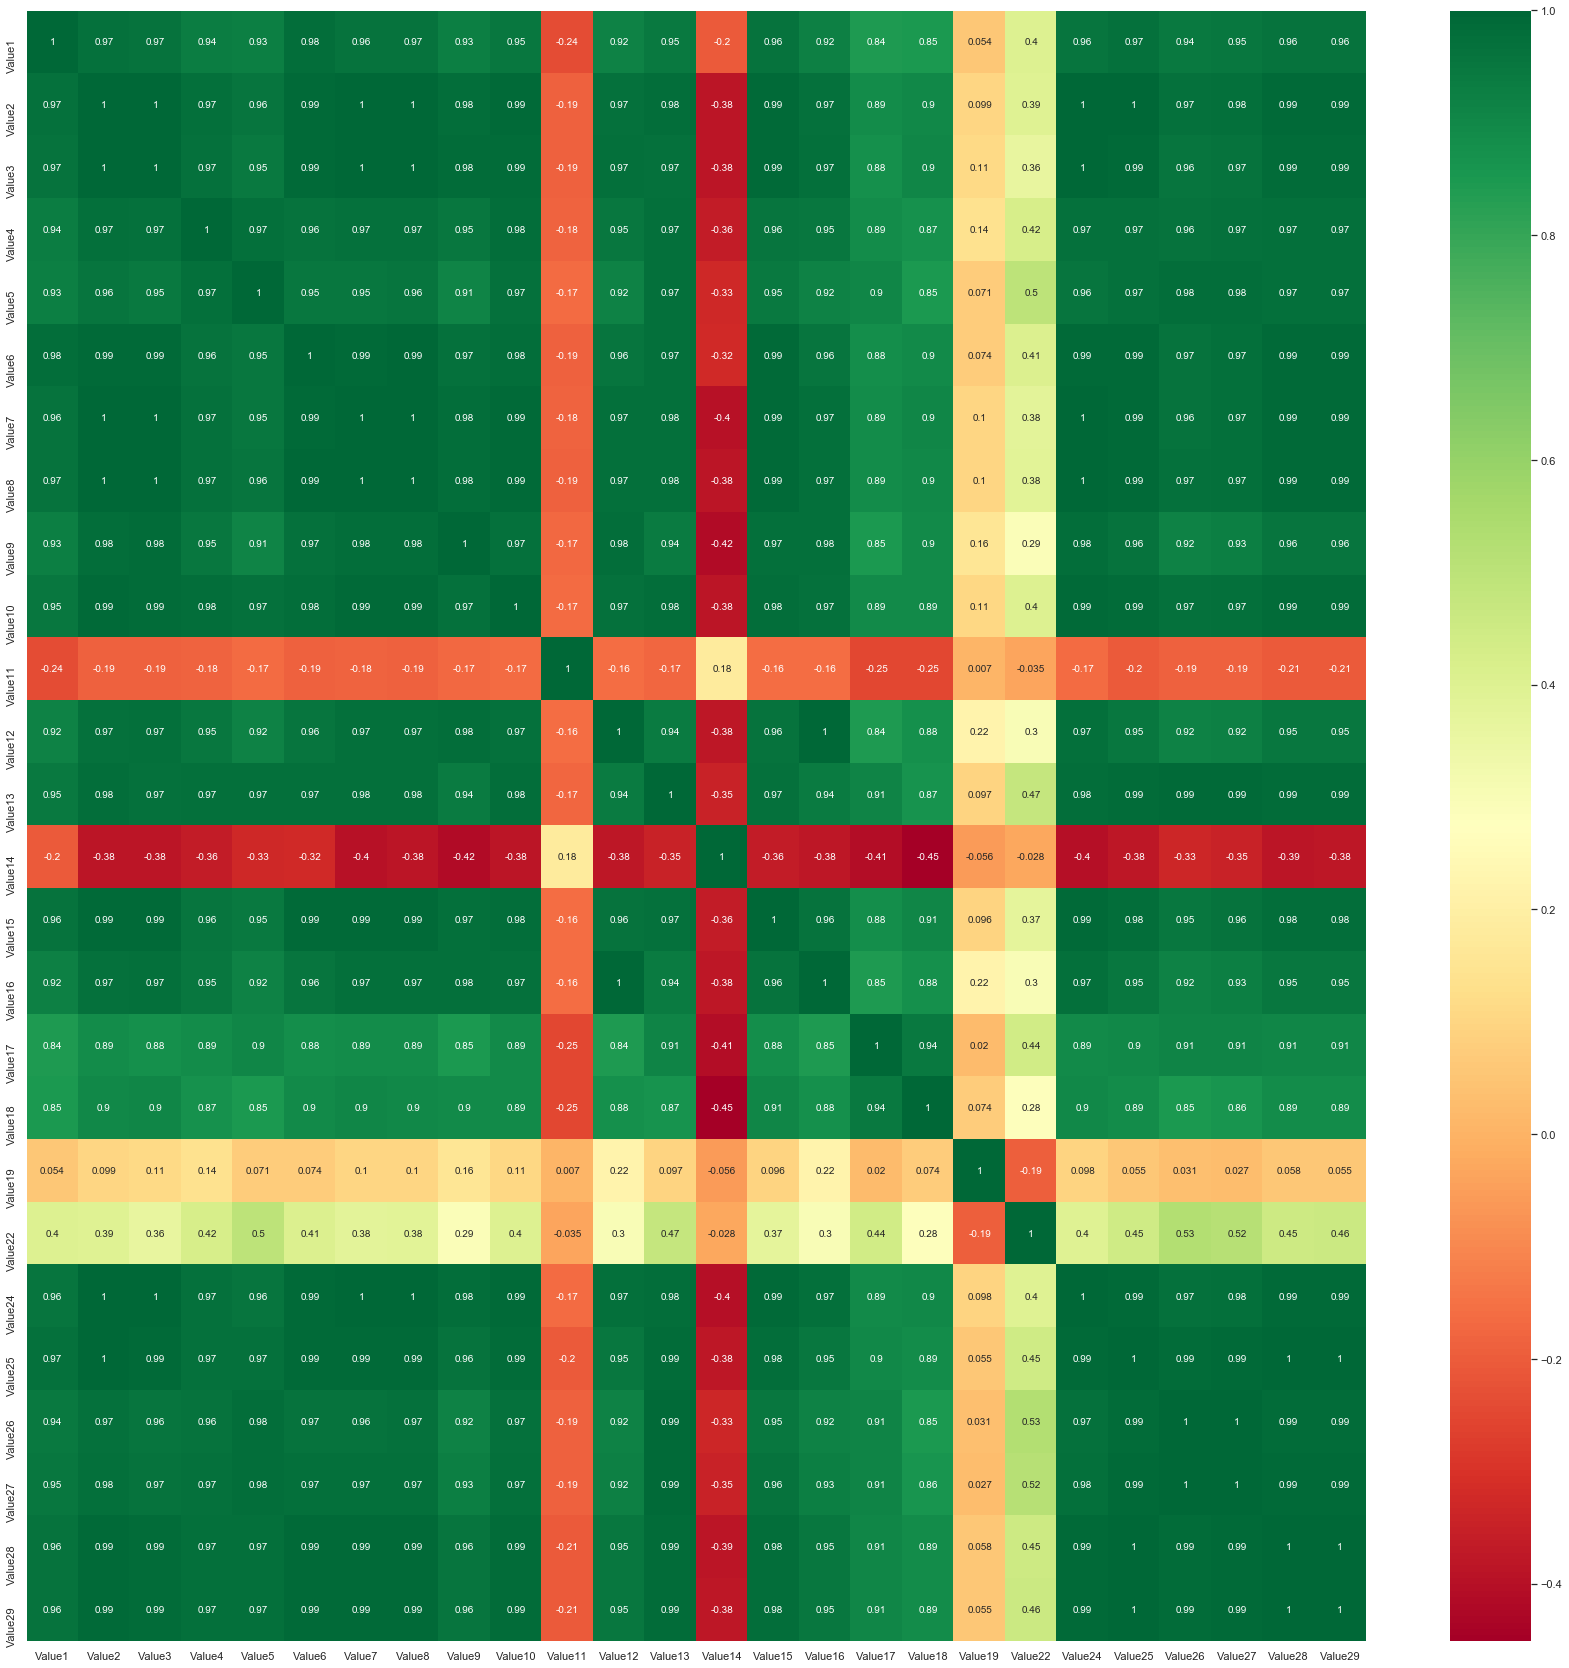

In [ ]:
dfa = pd.read_csv("data/Data_BFPT.csv")
dfa1=dfa[['Value1','Value2','Value3','Value4','Value5','Value6','Value7','Value8','Value9','Value10','Value11','Value12','Value13','Value14','Value15','Value16','Value17','Value18','Value19','Value22','Value24','Value25','Value26','Value27','Value28','Value29']]
dfa1

plt.subplots(figsize=(30, 30))
sns.heatmap(dfa1.corr(), annot=True, cmap="RdYlGn")
plt.show()

## 1.1 Check Zero

How much 0 value in each 'Value'?
<p>Value12 = 15553 (30%)
<p>Value13 = 973 (1,8%)
<p>Value16 = 15609 (30%)
<p>Value19 = 25333 (>50%) 
<p>Value21 = 36903 (>50%)
<p>Value24 = 770 (1,4%)

We consider Value20, Value23, Value21, Value19, Value16, Value12

## 1.2 Missing Value

In [4]:
dfa['Good29'].value_counts()

True     51769
False       71
Name: Good29, dtype: int64

Missing value<p>
1 = 255 <p>
2 = 76<p>
3 = 74<p>
4 = 75<p>
5 = 73<p>
6 = 65<p>
7 = 76<p>
8 = 73<p>
9 = 69<p>
10 = 73<p>
11 = 68<p>
12 = 72<p>
13 = 64<p>
14 = 65<p>
15 = 65<p>
16 = 68<p>
17 = 5416 (10%) <p>
18 = 5418 (10%) <p>
22 = 68<p>
24 = 83<p>
25 = 65<p>
26 = 73<p>
27 = 73<p>
28 = 71<p>
29 = 71 <p>

## 1.3 Only Take Its Value & Set Timestamp as Index

In [5]:
os.chdir(r"C:\Users\halim\Downloads")
df = pd.read_csv("Data BFPT A SLA6 180 hari 5 min Newest Modif.csv")
df

,Value1,Timestamp1,Value2,Value3,Value4,Value5,Value6,Value7,Value8,Value9,...,Value16,Value17,Value18,Value22,Value24,Value25,Value26,Value27,Value28,Value29
0,43.480654,2020-01-11T17:05:00Z,36.773418,36.791866,0.002000,0.001000,38.372665,36.659611,36.890816,0.002000,...,0.000000,6.749105,264.681052,0.020000,0.000000,38.359257,37.200142,37.195621,37.191868,36.800140
1,43.480654,2020-01-11T17:10:00Z,36.797253,36.763683,0.002000,0.001000,38.300865,36.603146,36.787621,0.002000,...,0.000000,6.749105,264.681052,0.020000,0.000000,38.246540,37.200142,37.188145,37.087620,36.800140
2,43.480654,2020-01-11T17:15:00Z,36.698959,36.660938,0.002000,0.001000,38.297901,36.726742,36.760941,0.002000,...,0.000000,6.749105,264.681052,0.020000,0.000000,38.238247,37.200142,37.098961,37.060940,36.894562
3,43.480654,2020-01-11T17:20:00Z,36.627934,36.649353,0.002000,0.001000,38.376701,36.600140,36.727371,0.002000,...,0.000000,6.749105,264.681052,0.020000,0.000000,38.232918,37.200142,37.069614,37.060715,36.800140
4,43.480654,2020-01-11T17:25:00Z,36.680653,36.680653,0.002000,0.001000,38.434982,36.600140,36.862236,0.002000,...,0.000000,6.749105,264.681052,0.020000,0.000000,38.389511,37.200142,37.080654,37.080654,36.800140
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51835,45.839886,2020-07-09T16:40:00Z,55.294193,55.900215,0.007055,0.010403,53.517853,62.000237,57.600220,0.010403,...,24.254200,8.511505,340.254852,0.080998,4486.000000,50.863087,55.854359,56.869999,47.600182,47.428932
51836,45.936367,2020-07-09T16:45:00Z,55.349186,55.884239,0.008000,0.010583,53.297432,62.000237,57.600220,0.010026,...,24.427906,8.511189,340.254852,0.080879,4485.745605,50.915234,55.888203,57.019657,47.600182,47.500183
51837,45.864624,2020-07-09T16:50:00Z,55.375023,55.822124,0.008000,0.010578,53.216545,62.143230,57.762871,0.010578,...,24.628229,8.481234,341.665344,0.082843,4484.477051,50.846893,56.046364,57.084599,47.602081,47.500183
51838,45.717434,2020-07-09T16:55:00Z,55.256035,55.845409,0.008000,0.010956,53.233059,62.000237,57.777122,0.010737,...,24.438585,8.476257,342.319397,0.089534,4484.000000,50.892651,55.921257,57.012829,47.664192,47.353580


## 1.4 Outliers - IQR Method

Value 4, 9, 11, 12, 14, 16, 22

In [6]:
Q1 = df['Value4'].quantile(0.25)
Q3 = df['Value4'].quantile(0.75)
IQR = Q3-Q1

up = Q3 +(1.5*IQR)
down = Q1 - (1.5*IQR)
print(up)
print(down)

0.019172638640156947
-0.00876029081700835


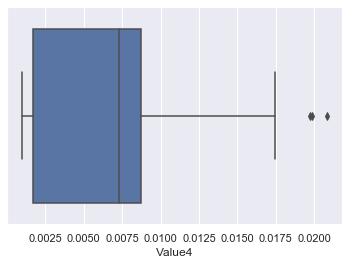

In [7]:
Outliers = df['Value4']
sns.boxplot(Outliers)
#z = np.abs(stats.zscore(Outliers))
#print("This is the z value  = ",z)
#threshold = 3
#print("This is where z above 3  = ",np.where(z > 3))
#Outliers = Outliers.mask(z > 3, mean(axis=0))

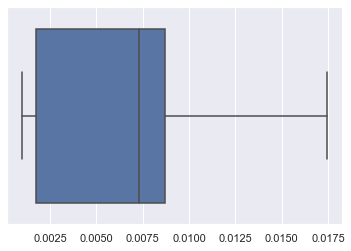

In [8]:
Outliers = df['Value4']
Outliers1 = np.where(Outliers>0.0180, np.mean(Outliers),Outliers)
sns.boxplot(Outliers1)
Outliers1.shape
df['Value4'] = Outliers1

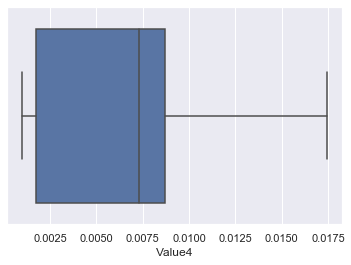

In [9]:
sns.boxplot(df['Value4'])

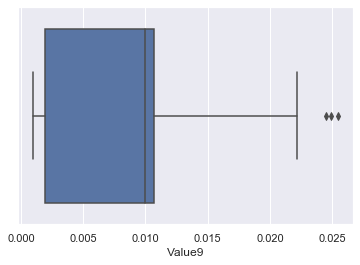

In [10]:
Outliers = df['Value9']
sns.boxplot(Outliers)

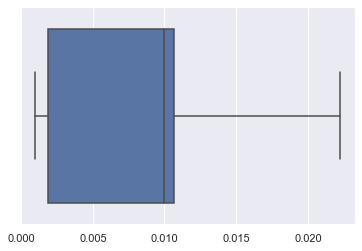

In [11]:
Outliers = df['Value9']
Outliers1 = np.where(Outliers>0.0225, np.mean(Outliers),Outliers)
sns.boxplot(Outliers1)
Outliers.shape
df['Value9'] = Outliers1

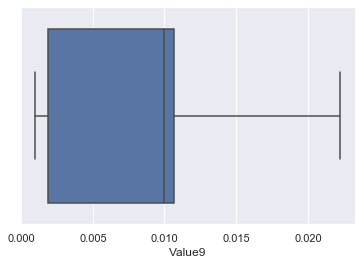

In [12]:
sns.boxplot(df['Value9'])

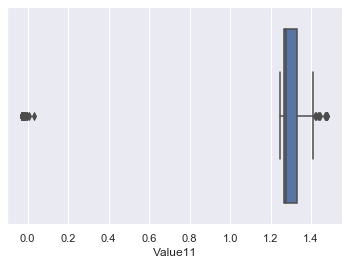

In [13]:
Outliers = df['Value11']
sns.boxplot(Outliers)

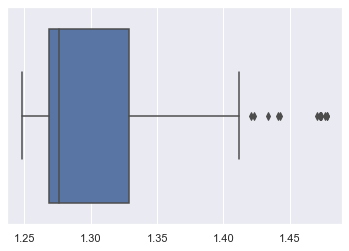

In [14]:
Outliers = df['Value11']
Outliers = np.where(Outliers<1.2, np.mean(Outliers),Outliers)
sns.boxplot(Outliers)
Outliers.shape
df['Value11']=Outliers

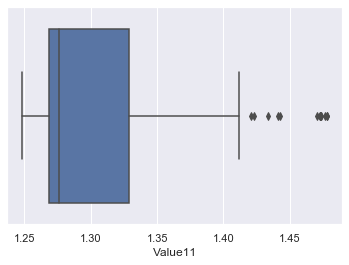

In [15]:
sns.boxplot(df['Value11'])

This is the z value  =  [1.10548889 1.12369063 1.10921069 ... 0.34716783 0.25118662 0.22029327]
This is where z above 3  =  (array([ 1600,  1601,  1602,  1603,  1604,  1605,  1606,  1607,  1608,
        1609,  1610,  1611,  1612,  1704,  1705,  1706,  1707,  1708,
        1709,  1710,  1711,  1712,  1713,  1714,  1715,  1716,  1717,
        1718,  1719,  1720,  1722,  1723,  1724,  1725,  3576,  3577,
        3578,  3579,  3580,  3581,  3582,  3583,  3584,  3585,  3586,
        3587,  3588,  3589,  3590,  3591,  3592,  3593,  3594,  3595,
        3597,  3638,  3640,  3641,  3642,  3647,  3648,  3649,  3650,
        3651,  3652,  3653,  3654,  3655,  3656,  3657,  3658,  3659,
        3660,  3661,  3662,  3663,  3664,  3665,  3666,  3667,  3668,
        3669,  3670,  3671,  3672,  3673,  3674,  3675,  3676,  3677,
        3678,  3679,  3680,  3681,  3682,  3683,  3684,  3685,  3686,
        3687,  3688,  3689,  3690,  3691,  3692,  3693,  3694,  3695,
        3696,  3697,  3698,  3699, 

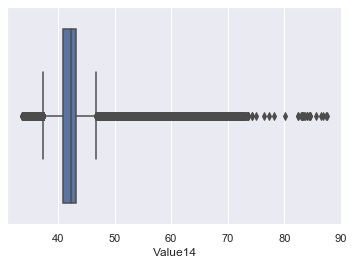

In [16]:
Outliers = df['Value14']
sns.boxplot(Outliers)
z = np.abs(stats.zscore(Outliers))
print("This is the z value  = ",z)
threshold = 3
print("This is where z above 3  = ",np.where(z > 3))

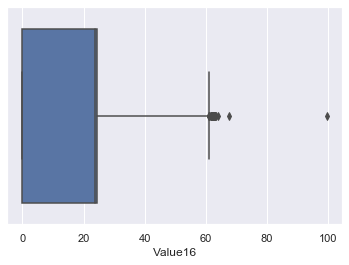

In [17]:
Outliers = df['Value16']
sns.boxplot(Outliers)

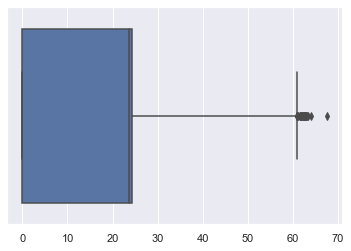

In [18]:
Outliers = df['Value16']
Outliers = np.where(Outliers>80, np.mean(Outliers),Outliers)
sns.boxplot(Outliers)
Outliers.shape
df['Value16']=Outliers

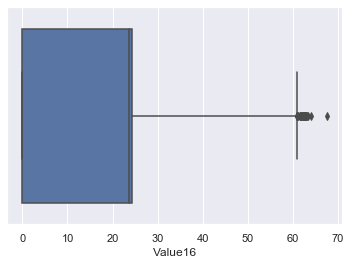

In [19]:
sns.boxplot(df['Value16'])

(array([ 1627,  1628,  1629,  1630,  1631,  1632,  1633,  1634,  1635,
        1636,  1637,  1638,  1639,  1640,  1641,  1642,  1643,  1644,
        1645,  1646,  1647,  1648,  1649,  1650,  1651,  1652,  1653,
        1654,  1655,  1656,  1657,  1658,  1659,  1660,  1661,  1662,
        1663,  1664,  1665,  1666,  1667,  1668,  1669,  1670,  1671,
        1672,  1673,  1674,  1675,  1676,  1677,  1678,  1679,  1680,
        1681,  1682,  1683,  1684,  1685,  1686,  1687,  1688,  1689,
        1690,  1691,  1692,  1693,  1694,  1695,  1696,  1697,  1698,
        1699,  1700,  1701,  1702,  1703,  1704,  1705,  1706,  1707,
        1733,  1734,  1735,  1754,  1755,  1756,  3488,  4851,  4852,
        4853,  4854,  4855,  4856,  4857,  4858,  4859,  4860,  4861,
        4862,  4863,  4864,  4865,  4866,  4867,  4868,  4869,  4870,
        4871,  4872,  4873,  4874,  4875,  4876,  4877,  4878,  4879,
        4880,  4881,  4882,  4883,  4884,  4885,  4886,  4887,  4888,
        4889,  4890

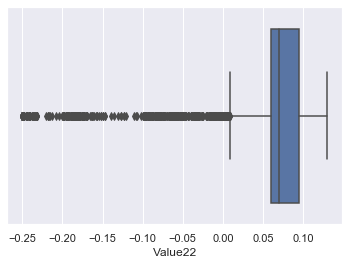

In [20]:
Outliers = df['Value22']
sns.boxplot(Outliers)
z = np.abs(stats.zscore(Outliers))
#print("This is the z value  = ",z)
threshold = 3
#print("This is where z above 3  = ",np.where(z > 3))
print(np.where(z>3))

Conclusion: Consider Value 12,16,17,18

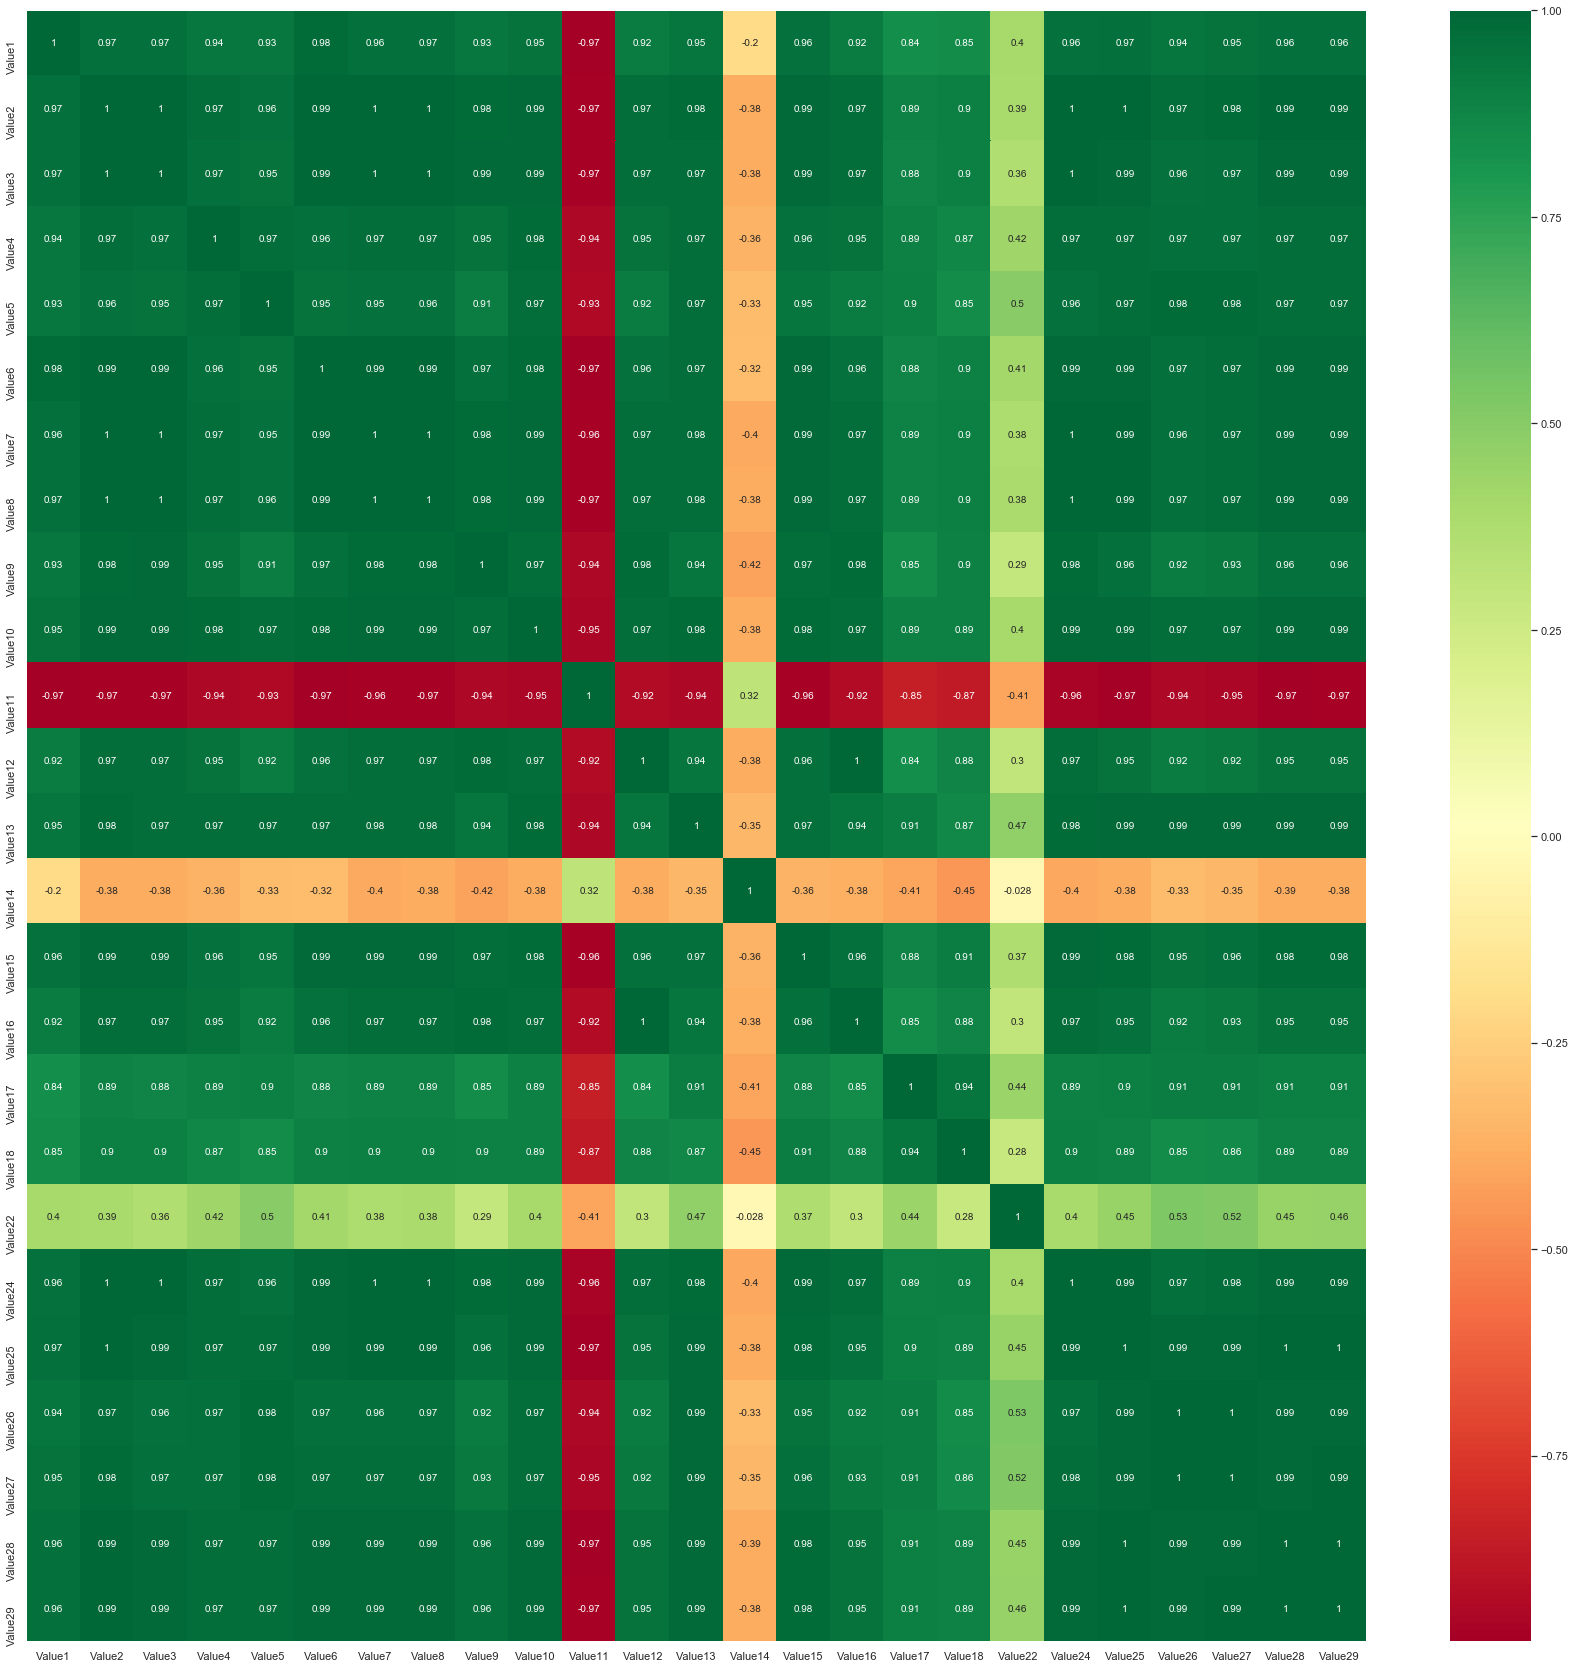

In [21]:
df_new=df[['Value1','Value2','Value3','Value4','Value5','Value6','Value7','Value8','Value9','Value10','Value11','Value12','Value13','Value14','Value15','Value16','Value17','Value18','Value22','Value24','Value25','Value26','Value27','Value28','Value29']]
df_new

plt.subplots(figsize=(30, 30))
sns.heatmap(df_new.corr(), annot=True, cmap="RdYlGn")
plt.show()

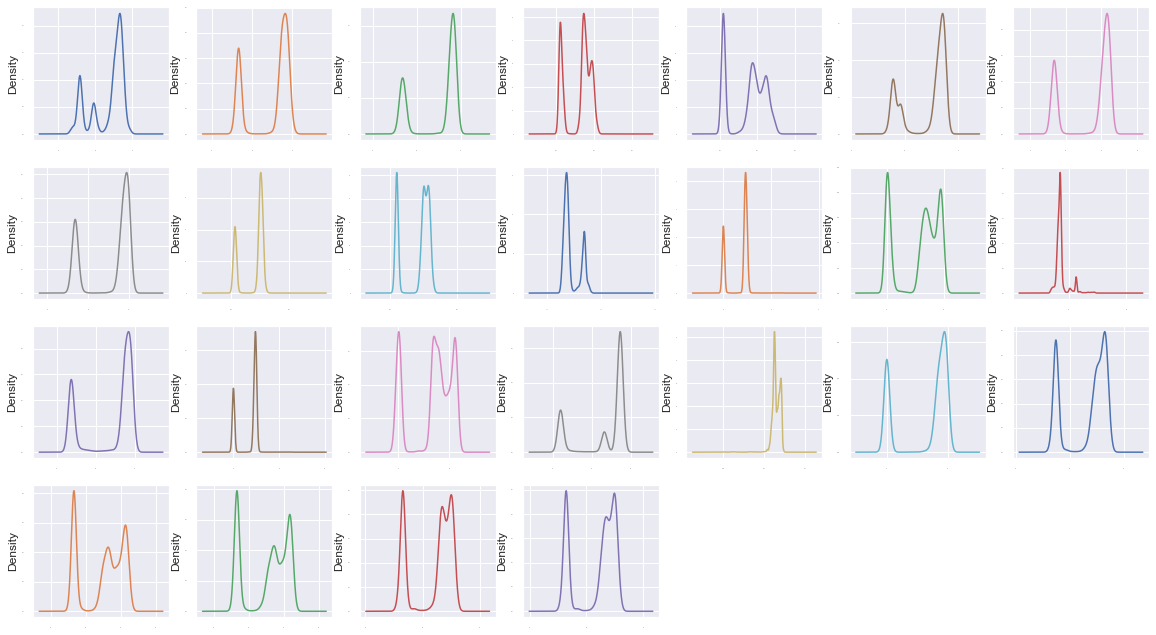

In [22]:
df_new.plot(kind='density', subplots=True, layout=(7,7), sharex=False, legend=False, fontsize=1,figsize=(20,20))
plt.show()

Using Autoencoder

In [23]:
#1          "Bearing 1 Drain Oil Temperature",
#2          "Bearing 1 Left Metal Temperature",
#3          "Bearing 1 Right Metal Temperature",
#4          "Bearing 1X Axis Vibration",
#5          "Bearing 1Y Axis Vibration",
#6          "Bearing 2 Drain Oil Temperature",
#7          "Bearing 2 Left Metal Temperature",
#8          "Bearing 2 Right Metal Temperature",
#9          "Bearing 2X Axis Vibration",
#10          "Bearing 2Y Axis Vibration",
#11          "Bearing Oil Pressure",
#12          "Control Oil Pressure",
#13          "Discharge Flow",
#14          "Exhaust Steam Temperature",
#15          "Feedwater Outlet Temperature",
#16                "Governor Valve Position",
#17  "Inlet Steam Pressure",
#18  "Inlet Steam Temperature",
#19  "Recirculation Flow",
#20  "Recirculation Flow Control Valve Position",
#21  "Rotor Eccentricity",
#22  "Rotor Position",
#23  "Running Status",
#24  "Speed",
#25  "Thrust Bearing Drain Oil Temperature",
#26  "Thrust Bearing Front Left Metal Temperature",
#27  "Thrust Bearing Front Right Metal Temperature",
#28  "Thrust Bearing Rear Left Metal Temperature",
#29  "Thrust Bearing Rear Right Metal Temperature"]

We try with value 14,17,18,22,9 (try "bearing 2")

In [24]:
df1 = df[['Timestamp1','Value14','Value17','Value18','Value22','Value9']]
df1 = df1.set_index("Timestamp1", drop = True)
df1

,Value14,Value17,Value18,Value22,Value9
Timestamp1,,,,,
2020-01-11T17:05:00Z,37.398209,6.749105,264.681052,0.020000,0.002000
2020-01-11T17:10:00Z,37.299667,6.749105,264.681052,0.020000,0.002000
2020-01-11T17:15:00Z,37.378059,6.749105,264.681052,0.020000,0.002000
2020-01-11T17:20:00Z,37.402752,6.749105,264.681052,0.020000,0.002000
2020-01-11T17:25:00Z,37.394520,6.749105,264.681052,0.020000,0.002000
...,...,...,...,...,...
2020-07-09T16:40:00Z,41.676929,8.511505,340.254852,0.080998,0.010403
2020-07-09T16:45:00Z,42.210407,8.511189,340.254852,0.080879,0.010026
2020-07-09T16:50:00Z,41.503635,8.481234,341.665344,0.082843,0.010578


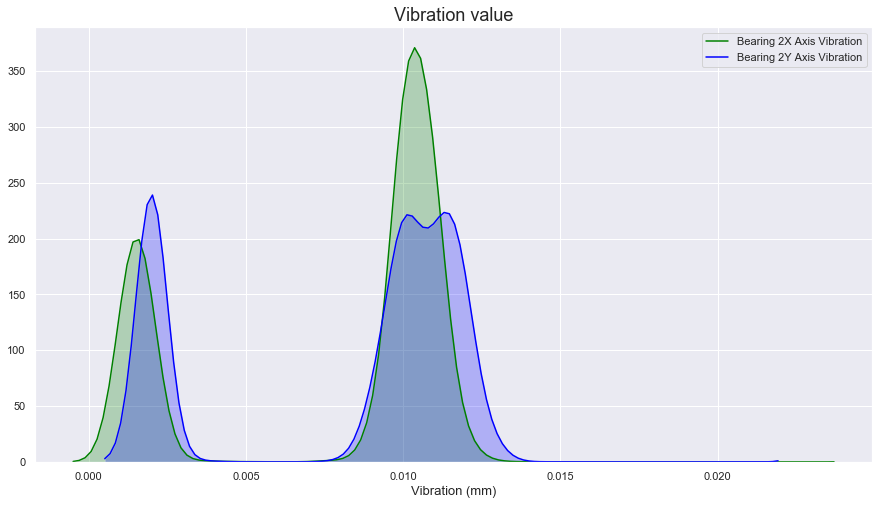

In [25]:
plt.figure(figsize=(15,8))
#sns.kdeplot(df1['Value6'], color="darkturquoise", shade=True)
#sns.kdeplot(df1['Value7'],color="lightcoral", shade=True)
#sns.kdeplot(df1['Value8'], color="yellow", shade=True)
sns.kdeplot(df1['Value9'],color="green", shade=True)
sns.kdeplot(df_new['Value10'], color="Blue", shade=True)
plt.legend(['Bearing 2X Axis Vibration', 'Bearing 2Y Axis Vibration'])
plt.title('Vibration value',fontsize=18)
plt.xlabel('Vibration (mm)',size=13)
plt.show()

In [26]:
#plt.figure(figsize=(15,8))
#sns.kdeplot(df1['Value6'], color="darkturquoise", shade=True)
#sns.kdeplot(df1['Value7'],color="lightcoral", shade=True)
#sns.kdeplot(df1['Value8'], color="yellow", shade=True)
#sns.kdeplot(df1['Value9'],color="green", shade=True)
#sns.kdeplot(df1['Value10'], color="Blue", shade=True)
#plt.legend(['Bearing 2 Drain Oil Temperature','Bearing 2 Left Metal Temperature','Bearing 2 Right Metal Temperature'])
#plt.title('Temperature Value',fontsize=18)
#plt.xlabel('Temperature (Celcius)',size=13)
#plt.show()

Insight from PDF: This have 2 group of data

In [27]:
#df2 = df1[['Value9','Value10']]
#Anomaly = np.zeros((51840, 1))
#df2['Anomaly']= Anomaly
#df2.loc[df2['Value9'] < 0.005, 'Anomaly'] = 1
#df2

In [28]:
#plt.figure(figsize=(20,20))
#plt.scatter(df1['Value9'],df1['Value10'])

In [29]:
import numpy
from numpy import arange
from matplotlib import pyplot
from pandas import read_csv
from pandas import set_option
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_squared_error

In [30]:
array = df1.values
X = array[:,0:4]
Y = array[:,4]
validation_size = 0.20
seed = 7
X_train, X_validation, Y_train, Y_validation = train_test_split(X, Y,
test_size=validation_size, random_state=seed)

# Test options and evaluation metric
num_folds = 10
seed = 8
scoring = 'neg_mean_squared_error'

# Spot-Check Algorithms
models = []
models.append(('LR', LinearRegression()))
models.append(('LASSO', Lasso()))
models.append(('EN', ElasticNet()))
models.append(('KNN', KNeighborsRegressor()))
models.append(('CART', DecisionTreeRegressor()))
models.append(('SVR', SVR()))

# evaluate each model in turn
results = []
names = []
for name, model in models:
    kfold = KFold(n_splits=num_folds, random_state=seed, shuffle=True)
    cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %.10f (%.10f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

LR: -0.0000032872 (0.0000002103)
LASSO: -0.0000169421 (0.0000002055)
EN: -0.0000169421 (0.0000002055)
KNN: -0.0000007661 (0.0000001280)
CART: -0.0000004482 (0.0000001038)
SVR: -0.0000316140 (0.0000008656)


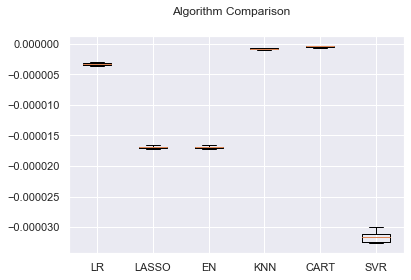

In [31]:
fig = pyplot.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
pyplot.boxplot(results)
ax.set_xticklabels(names)
pyplot.show()

In [32]:
pipelines = []
pipelines.append(('ScaledLR', Pipeline([('Scaler', StandardScaler()),('LR',LinearRegression())])))
pipelines.append(('ScaledLASSO', Pipeline([('Scaler', StandardScaler()),('LASSO',Lasso())])))
pipelines.append(('ScaledEN', Pipeline([('Scaler', StandardScaler()),('EN',ElasticNet())])))
pipelines.append(('ScaledKNN', Pipeline([('Scaler', StandardScaler()),('KNN',KNeighborsRegressor())])))
pipelines.append(('ScaledCART', Pipeline([('Scaler', StandardScaler()),('CART',DecisionTreeRegressor())])))
pipelines.append(('ScaledSVR', Pipeline([('Scaler', StandardScaler()),('SVR', SVR())])))
results = []
names = []
for name, model in pipelines:
    kfold = KFold(n_splits=num_folds, random_state=seed, shuffle=True)
    cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %.10f (%.10f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

ScaledLR: -0.0000032872 (0.0000002103)
ScaledLASSO: -0.0000169421 (0.0000002055)
ScaledEN: -0.0000169421 (0.0000002055)
ScaledKNN: -0.0000003558 (0.0000000599)
ScaledCART: -0.0000004432 (0.0000000971)
ScaledSVR: -0.0000316140 (0.0000008656)


In [33]:
scaler = StandardScaler().fit(X_train)
rescaledX = scaler.transform(X_train)
k_values = numpy.array([1,3,5,7,9,11,13,15,17,19,21])
param_grid = dict(n_neighbors=k_values)
model = KNeighborsRegressor()
kfold = KFold(n_splits=num_folds, random_state=seed, shuffle=True)
grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scoring, cv=kfold)
grid_result = grid.fit(rescaledX, Y_train)
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%.10f (%.10f) with: %r" % (mean, stdev, param))

Best: -0.000000 using {'n_neighbors': 5}
-0.0000004621 (0.0000000656) with: {'n_neighbors': 1}
-0.0000003572 (0.0000000471) with: {'n_neighbors': 3}
-0.0000003559 (0.0000000597) with: {'n_neighbors': 5}
-0.0000003615 (0.0000000616) with: {'n_neighbors': 7}
-0.0000003694 (0.0000000668) with: {'n_neighbors': 9}
-0.0000003718 (0.0000000717) with: {'n_neighbors': 11}
-0.0000003781 (0.0000000719) with: {'n_neighbors': 13}
-0.0000003837 (0.0000000796) with: {'n_neighbors': 15}
-0.0000003890 (0.0000000804) with: {'n_neighbors': 17}
-0.0000003952 (0.0000000806) with: {'n_neighbors': 19}
-0.0000004021 (0.0000000804) with: {'n_neighbors': 21}


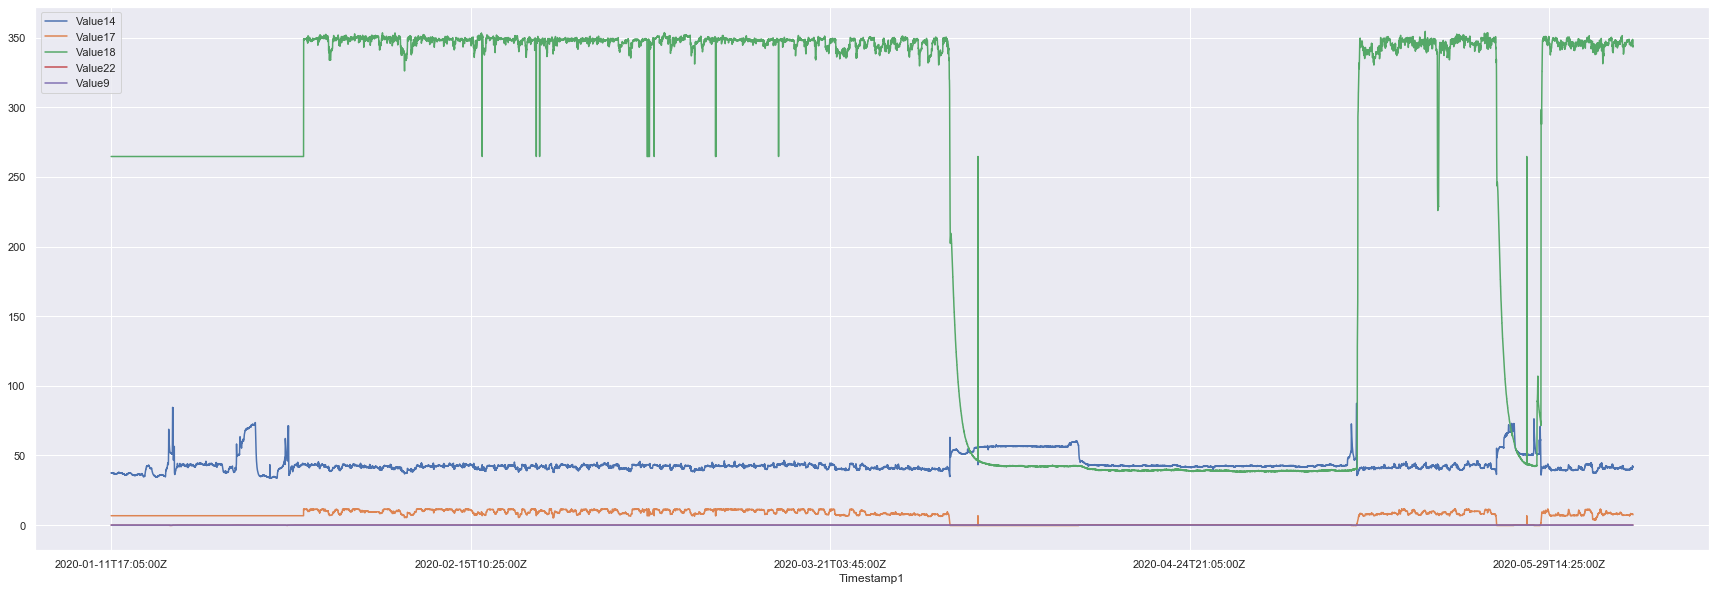

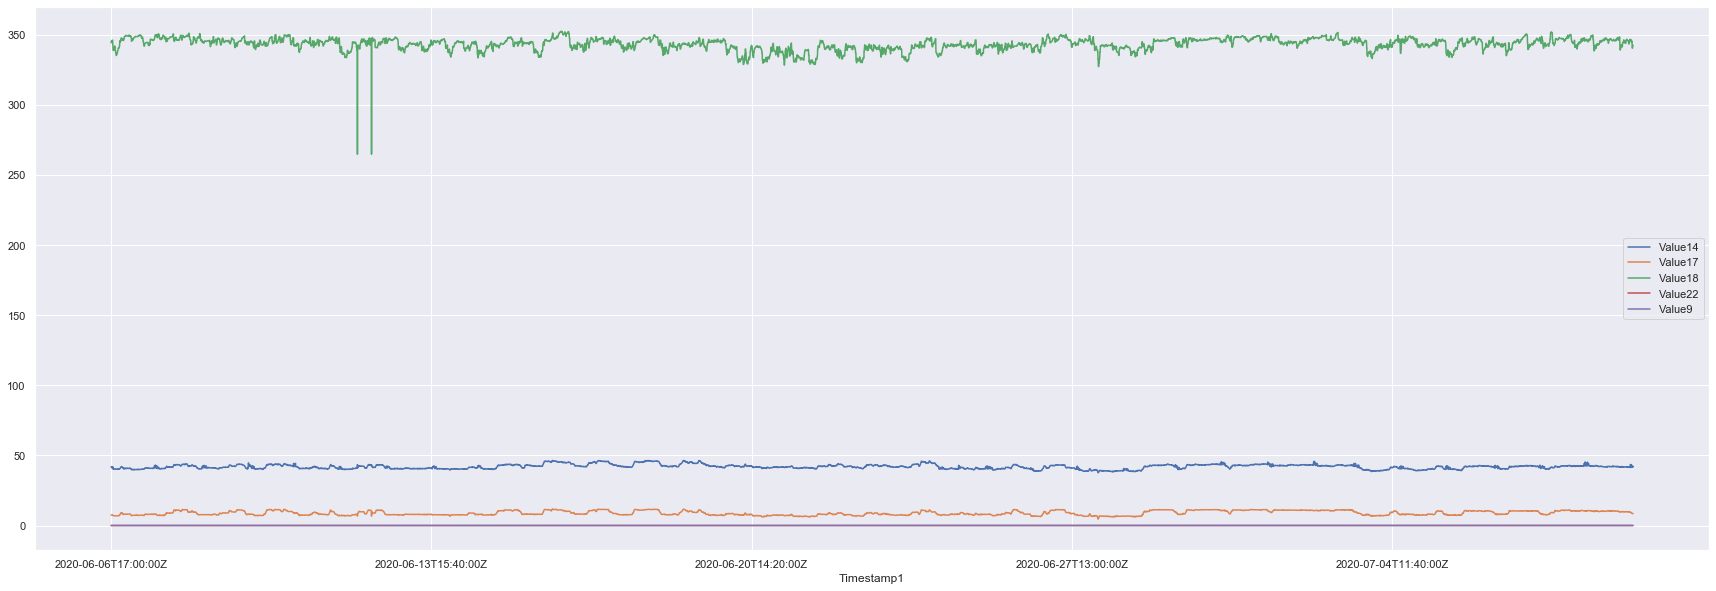

In [183]:
df_train = df1['2020-01-11T17:05:00Z':'2020-06-06T17:00:00Z']
df_test = df1['2020-06-06T17:00:00Z':]
df_train.plot(figsize = (30,10))
df_test.plot(figsize = (30,10))

In [64]:
df1.values[:,0:5]

array([[3.73982086e+01, 6.74910460e+00, 2.64681052e+02, 1.99999809e-02,
        1.99997425e-03],
       [3.72996674e+01, 6.74910460e+00, 2.64681052e+02, 1.99999809e-02,
        1.99997425e-03],
       [3.73780594e+01, 6.74910460e+00, 2.64681052e+02, 1.99999809e-02,
        1.99997425e-03],
       ...,
       [4.15036354e+01, 8.48123360e+00, 3.41665344e+02, 8.28434825e-02,
        1.05779683e-02],
       [4.20232620e+01, 8.47625732e+00, 3.42319397e+02, 8.95335451e-02,
        1.07369768e-02],
       [4.21905136e+01, 8.47625732e+00, 3.42319397e+02, 8.98605362e-02,
        1.07105812e-02]])

In [ ]:
scaler = preprocessing.MinMaxScaler()
X_train = pd.DataFrame(scaler.fit_transform(df_train),columns=df_train.columns,index=df_train.index)
# Random shuffle training data
X_train.sample(frac=1)
X_test = pd.DataFrame(scaler.transform(df_test),columns=df_test.columns,index=df_test.index)

In [ ]:
seed(10)
tf.random.set_seed(10)
act_func = 'elu'

# Input layer:
model=Sequential()
# First hidden layer, connected to input vector X. 
model.add(Dense(10,activation=act_func,
                kernel_initializer='glorot_uniform',
                kernel_regularizer=regularizers.l2(0.0),
                input_shape=(X_train.shape[1],)
               )
         )

model.add(Dense(2,activation=act_func,
                kernel_initializer='glorot_uniform'))

model.add(Dense(10,activation=act_func,
                kernel_initializer='glorot_uniform'))

model.add(Dense(X_train.shape[1],
                kernel_initializer='glorot_uniform'))

model.compile(loss='mse',optimizer='adam')

# Train model for 100 epochs, batch size of 10: 
NUM_EPOCHS=100
BATCH_SIZE=10

In [ ]:
history=model.fit(np.array(X_train),np.array(X_train),
                  batch_size=BATCH_SIZE, 
                  epochs=NUM_EPOCHS,
                  validation_split=0.05,
                  verbose = 1)

In [ ]:
plt.plot(history.history['loss'],
         'b',
         label='Training loss')
plt.plot(history.history['val_loss'],
         'r',
         label='Validation loss')
plt.legend(loc='upper right')
plt.xlabel('Epochs')
plt.ylabel('Loss, [mse]')
plt.show()

In [ ]:
X_pred = model.predict(np.array(X_train))
X_pred = pd.DataFrame(X_pred, 
                      columns=X_train.columns)
X_pred.index = X_train.index

scored = pd.DataFrame(index=X_train.index)
scored['Loss_mae'] = np.mean(np.abs(X_pred-X_train), axis = 1)
plt.figure()
sns.distplot(scored['Loss_mae'],
             bins = 10, 
             kde= True,
            color = 'blue');

In [ ]:
X_pred = model.predict(np.array(X_test))
X_pred = pd.DataFrame(X_pred, 
                      columns=X_test.columns)
X_pred.index = X_test.index

scored = pd.DataFrame(index=X_test.index)
scored['Loss_mae'] = np.mean(np.abs(X_pred-X_test), axis = 1)
scored['Threshold'] = 0.025
scored['Anomaly'] = scored['Loss_mae'] > scored['Threshold']
scored.head()

In [ ]:
X_pred_train = model.predict(np.array(X_train))
X_pred_train = pd.DataFrame(X_pred_train, 
                      columns=X_train.columns)
X_pred_train.index = X_train.index

scored_train = pd.DataFrame(index=X_train.index)
scored_train['Loss_mae'] = np.mean(np.abs(X_pred_train-X_train), axis = 1)
scored_train['Threshold'] = 0.025
scored_train['Anomaly'] = scored_train['Loss_mae'] > scored_train['Threshold']
scored = pd.concat([scored_train, scored])

In [ ]:
scored.plot(logy=True,  figsize = (25,10), color = ['blue','red'])

In [ ]:
plt.figure(figsize=(30,10))
#plt.plot(df1['Value1'],linewidth=0.8, color='blue')#Bearing 1 Drain Oil Temperature
#plt.plot(df1['Value2'],linewidth=0.8, color='red')#Bearing 1 Left Metal Temperature       
#plt.plot(df1['Value3'],linewidth=0.8, color='black')#Bearing 1 Right Metal Temperature
plt.plot(df1['Value4'],linewidth=0.8, color='green')#Bearing 1X Axis Vibration
#plt.plot(df1['Value5'],linewidth=0.8, color='yellow')#Bearing 1Y Axis Vibration
#plt.plot(df1['Value6'],linewidth=0.8, color='purple')
#plt.plot(df1['Value7'],linewidth=0.8, color='orange')
#plt.plot(df1['Value8'],linewidth=0.8, color='pink')
plt.ylabel('Vibration')
plt.xlabel('Time')
plt.title('Bottom X Axis Vibration (Value 1)')
plt.grid(True)
plt.show()

In [ ]:
X=df['Value4']
y=df['Value5']
df_train = df1['2020-01-11T17:05:00Z':'2020-05-11T17:05:00Z']
df_test = df1['2020-05-11T17:10:00Z':]
df_train.plot(figsize = (30,10))

In [ ]:
a=df['Value4']-df['Value5']
plt.figure(figsize=(20,5))
#plt.plot(df['Value4'],linewidth=0.8)
#plt.plot(df['Value5'],linewidth=0.8)
plt.plot(a,linewidth=0.8)
plt.ylabel('Vibration')
plt.xlabel('Time')
plt.title('Bottom X Axis Vibration (Value 1)')
plt.grid(True)
plt.show()

In [ ]:
df1['Value20'].value_counts()

In [ ]:
dataset_train = df2['2020-01-11T17:05:00Z':'2020-05-11T17:05:00Z']
dataset_test = df2['2020-05-11T17:10:00Z':]
scaler = preprocessing.MinMaxScaler()

X_train = pd.DataFrame(scaler.fit_transform(dataset_train), 
                              columns=dataset_train.columns, 
                              index=dataset_train.index)
# Random shuffle training data
X_train.sample(frac=1)

X_test = pd.DataFrame(scaler.transform(dataset_test), 
                             columns=dataset_test.columns, 
                             index=dataset_test.index)

plt.figure(figsize=(20,5))
plt.plot(X_train['Value1'],linewidth=0.8)
plt.plot(X_test['Value1'],linewidth=0.8)
plt.ylabel('Vibration')
plt.xlabel('Time')
plt.title('Bottom X Axis Vibration (Value 1)')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, svd_solver= 'full')
X_train_PCA = pca.fit_transform(X_train)
X_train_PCA = pd.DataFrame(X_train_PCA)
X_train_PCA.index = X_train.index

X_test_PCA = pca.transform(X_test)
X_test_PCA = pd.DataFrame(X_test_PCA)
X_test_PCA.index = X_test.index

In [ ]:
def cov_matrix(data, verbose=False):
    covariance_matrix = np.cov(data, rowvar=False)
    if is_pos_def(covariance_matrix):
        inv_covariance_matrix = np.linalg.inv(covariance_matrix)
        if is_pos_def(inv_covariance_matrix):
            return covariance_matrix, inv_covariance_matrix
        else:
            print("Error: Inverse of Covariance Matrix is not positive definite!")
    else:
        print("Error: Covariance Matrix is not positive definite!")

In [ ]:
def MahalanobisDist(inv_cov_matrix, mean_distr, data, verbose=False):
    inv_covariance_matrix = inv_cov_matrix
    vars_mean = mean_distr
    diff = data - vars_mean
    md = []
    for i in range(len(diff)):
        md.append(np.sqrt(diff[i].dot(inv_covariance_matrix).dot(diff[i])))
    return md

In [ ]:
def MD_detectOutliers(dist, extreme=False, verbose=False):
    k = 3. if extreme else 2.
    threshold = np.mean(dist) * k
    outliers = []
    for i in range(len(dist)):
        if dist[i] >= threshold:
            outliers.append(i)  # index of the outlier
    return np.array(outliers)

In [ ]:
def MD_threshold(dist, extreme=False, verbose=False):
    k = 3. if extreme else 2.
    threshold = np.mean(dist) * k
    return threshold

In [ ]:
def is_pos_def(A):
    if np.allclose(A, A.T):
        try:
            np.linalg.cholesky(A)
            return True
        except np.linalg.LinAlgError:
            return False
    else:
        return False

In [ ]:
data_train = np.array(X_train_PCA.values)
data_test = np.array(X_test_PCA.values)

In [ ]:
cov_matrix, inv_cov_matrix  = cov_matrix(data_train)

In [ ]:
mean_distr = data_train.mean(axis=0)

In [ ]:
dist_test = MahalanobisDist(inv_cov_matrix, mean_distr, data_test, verbose=False)
dist_train = MahalanobisDist(inv_cov_matrix, mean_distr, data_train, verbose=False)
threshold = MD_threshold(dist_train, extreme = True)

In [ ]:
plt.figure()
sns.distplot(np.square(dist_train),
             bins = 30, 
             kde= False);
plt.xlim([0.0,15])

In [ ]:
plt.figure()
sns.distplot(dist_train,
             bins = 40, 
             kde= True, 
            color = 'green');
plt.xlim([0.0,5])
plt.xlabel('Mahalanobis dist')

In [ ]:
anomaly_train = pd.DataFrame()
anomaly_train['Mob dist']= dist_train
anomaly_train['Thresh'] = threshold
# If Mob dist above threshold: Flag as anomaly
anomaly_train['Anomaly'] = anomaly_train['Mob dist'] > anomaly_train['Thresh']
anomaly_train.index = X_train_PCA.index
anomaly = pd.DataFrame()
anomaly['Mob dist']= dist_test
anomaly['Thresh'] = threshold
# If Mob dist above threshold: Flag as anomaly
anomaly['Anomaly'] = anomaly['Mob dist'] > anomaly['Thresh']
anomaly.index = X_test_PCA.index
anomaly.head()

In [ ]:
anomaly_alldata = pd.concat([anomaly_train, anomaly])
anomaly_alldata.to_csv('Anomaly_distance.csv')

In [ ]:
anomaly_alldata.plot(logy=True, figsize = (20,6), ylim = [1e-1,1e3], color = ['green','red'])

In [ ]:
df['Value19'].value_counts()

In [ ]:
dataset_train = df['2020-01-11 17:05:00':'2020-02-11 23:55:00']
#dataset_test = df['2004-02-13 23:52:39':]
#dataset_train.plot(figsize = (12,6))

In [ ]:
data_dir = r"C:\Users\halim\Downloads"
merged_data = pd.DataFrame()

for filename in os.listdir(data_dir):
    print(filename)
    #print(dataset=pd.read_csv(os.path.join(data_dir, filename), sep='\t'))
    #dataset_mean_abs = np.array(dataset.abs().mean())
    #dataset_mean_abs = pd.DataFrame(dataset_mean_abs.reshape(1,4))
    #dataset_mean_abs.index = [filename]
    #merged_data = merged_data.append(dataset_mean_abs)

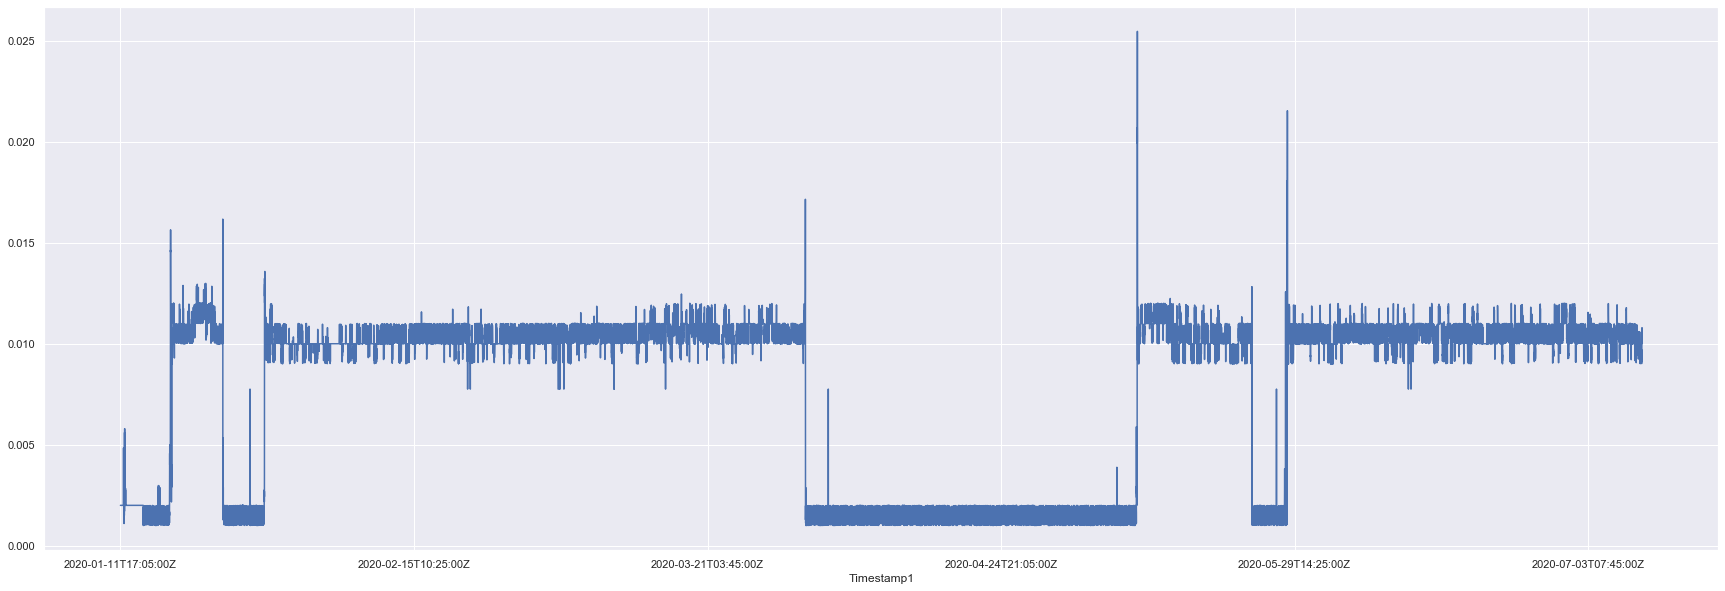

In [136]:
df1['Value9'].plot(figsize = (30,10))

Hakikatnya semua rotating machine menghasilkan getaran yang merupakan fungsi kelurusan dan keseimbangan dari komponen yang berputar

There is so much methode for predictive maintenance:
    1. Vibration analysis
    2. Thermography 
    3. Parameter process
    4. Ultrasonic 
    5. Visual inspection 
    6. Tribology


In [1]:
from pydataset import data
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

X=df1[['Value14','Value17','Value18','Value22']]
y=df1['Value9']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.3,random_state=0)
clf=KNeighborsRegressor(5)
clf.fit(X_train,y_train)
y_pred=clf.predict(X_test)
y_predreal=clf.predict(X)

#Column2': data[:, 1]
#dataset1 = pd.DataFrame({'Column1': y_pred[:, 0]})
#numpy_data = np.array([1,2,1,2,5,6,7,5,7,4,3])
print(mean_squared_error(y_test,y_pred))

NameError: name 'df1' is not defined

In [49]:
os.chdir(r"C:\Users\halim\Downloads")
df = pd.read_csv("Data BFPT A SLA6 180 hari 5 min Newest Modif.csv")
df

,Value1,Timestamp1,Value2,Value3,Value4,Value5,Value6,Value7,Value8,Value9,...,Value16,Value17,Value18,Value22,Value24,Value25,Value26,Value27,Value28,Value29
0,43.480654,2020-01-11T17:05:00Z,36.773418,36.791866,0.002000,0.001000,38.372665,36.659611,36.890816,0.002000,...,0.000000,6.749105,264.681052,0.020000,0.000000,38.359257,37.200142,37.195621,37.191868,36.800140
1,43.480654,2020-01-11T17:10:00Z,36.797253,36.763683,0.002000,0.001000,38.300865,36.603146,36.787621,0.002000,...,0.000000,6.749105,264.681052,0.020000,0.000000,38.246540,37.200142,37.188145,37.087620,36.800140
2,43.480654,2020-01-11T17:15:00Z,36.698959,36.660938,0.002000,0.001000,38.297901,36.726742,36.760941,0.002000,...,0.000000,6.749105,264.681052,0.020000,0.000000,38.238247,37.200142,37.098961,37.060940,36.894562
3,43.480654,2020-01-11T17:20:00Z,36.627934,36.649353,0.002000,0.001000,38.376701,36.600140,36.727371,0.002000,...,0.000000,6.749105,264.681052,0.020000,0.000000,38.232918,37.200142,37.069614,37.060715,36.800140
4,43.480654,2020-01-11T17:25:00Z,36.680653,36.680653,0.002000,0.001000,38.434982,36.600140,36.862236,0.002000,...,0.000000,6.749105,264.681052,0.020000,0.000000,38.389511,37.200142,37.080654,37.080654,36.800140
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51835,45.839886,2020-07-09T16:40:00Z,55.294193,55.900215,0.007055,0.010403,53.517853,62.000237,57.600220,0.010403,...,24.254200,8.511505,340.254852,0.080998,4486.000000,50.863087,55.854359,56.869999,47.600182,47.428932
51836,45.936367,2020-07-09T16:45:00Z,55.349186,55.884239,0.008000,0.010583,53.297432,62.000237,57.600220,0.010026,...,24.427906,8.511189,340.254852,0.080879,4485.745605,50.915234,55.888203,57.019657,47.600182,47.500183
51837,45.864624,2020-07-09T16:50:00Z,55.375023,55.822124,0.008000,0.010578,53.216545,62.143230,57.762871,0.010578,...,24.628229,8.481234,341.665344,0.082843,4484.477051,50.846893,56.046364,57.084599,47.602081,47.500183
51838,45.717434,2020-07-09T16:55:00Z,55.256035,55.845409,0.008000,0.010956,53.233059,62.000237,57.777122,0.010737,...,24.438585,8.476257,342.319397,0.089534,4484.000000,50.892651,55.921257,57.012829,47.664192,47.353580


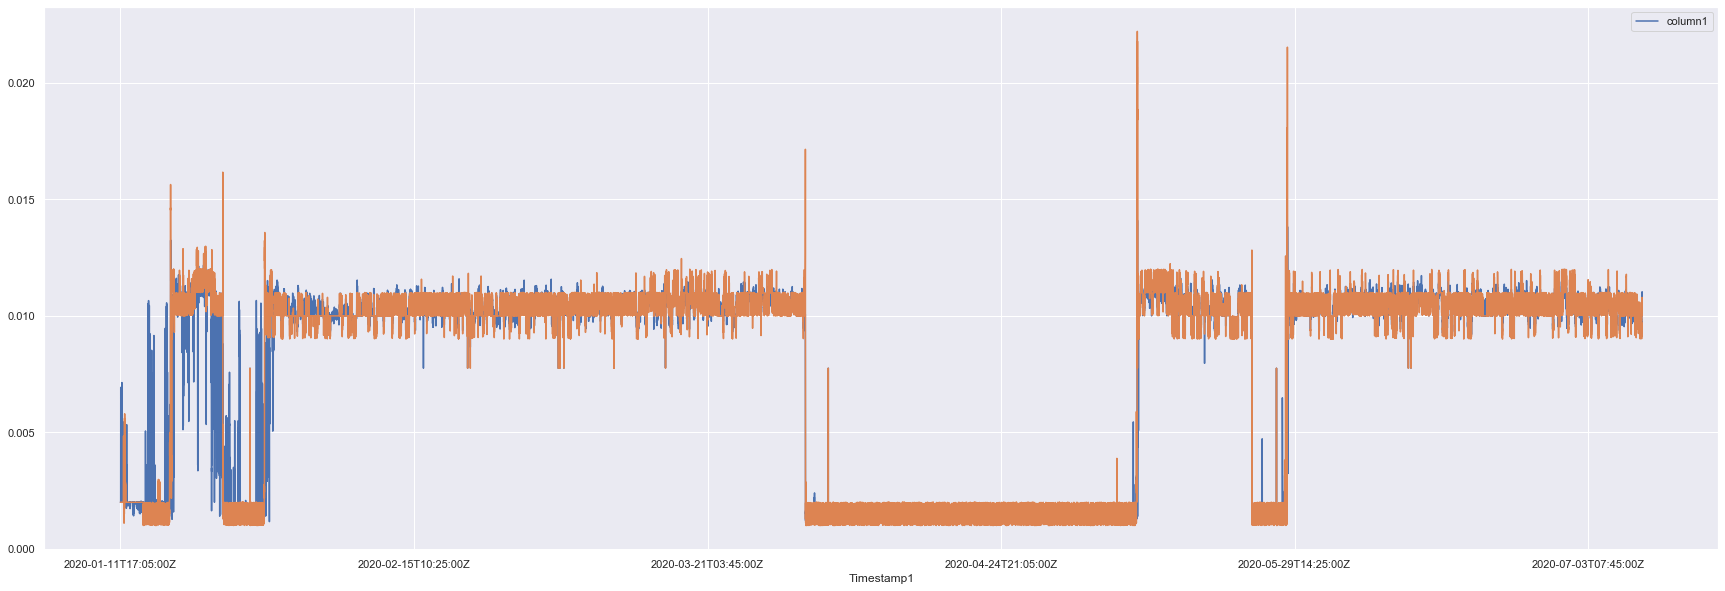

In [50]:
dfaa = pd.DataFrame(data=y_predreal, index=df['Timestamp1'], columns=["column1"])
#print(y_predreal)
#print(numpy_data)
dfaa.plot(figsize=(30,10))
df1['Value9'].plot(figsize=(30,10))

In [34]:
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf 
from statsmodels.tsa.seasonal import seasonal_decompose 
from pmdarima import auto_arima                        
from sklearn.metrics import mean_squared_error
from statsmodels.tools.eval_measures import rmse
import warnings
warnings.filterwarnings("ignore")

In [36]:
auto_arima(df1['Value9'], m=12,max_p=7, max_d=5,max_q=7).summary()

MemoryError: Unable to allocate 6.33 MiB for an array with shape (16, 51840) and data type float64